In [1]:
# open a fasta file  
# gc content 
# finding the encoding elements (genes) (from start to stop)
# lenght of genes 
# translate to amino acids, amionoacids content 
# forecasting the secondary structure 
# made by Alesya Kovaleva, 2020

In [2]:
# the parameter address is the address to a FASTA file with a genome
# function returns one string that's composed only from A, T, G, C
def opener (address):
    with open(address, mode = "r", encoding = "UTF-8") as myfile:
        text = myfile.read()
        text = text[text.find("\n") + 1: -1]
        text = text.replace("\n", "")
        return text

In [3]:
# the parameter genome is a string, which is a genome (composed only from A, T, G, C)
# prints out the gc-content
def get_gc (genome):
    gc = genome.count("G") + genome.count("C") 
    gc_content = round(gc / len(genome) * 100, 2)
    print(f"The guanine-cytosine content in your bacteria is {gc_content} %")   

In [4]:
# to work with this function you need to import module re (by from re import *)
# the parameter genome is a string, which is a genome (composed only from A, T, G, C)
# prints out the length of encoding part of genome and suchlike
# returns a list of all foung genes which star with a start-codon and end with a stop-codon
def get_genes (genome):
    genes = findall(r'ATG(?:(?!TAA|TAG|TGA)(?:\w{3})){19,}?(?:TAA|TAG|TGA)', genome)
    
    length_en = sum([len(genes[i]) for i in range(len(genes))])
    ratio = round(length_en / len(genome) * 100, 2)
    print(f'''Length of encoding part of genome is {length_en} bp.
Length of non-coding part of genome is {len(genome) - length_en} bp.
Relation of encoding part of genome to the non-coding part is {ratio}% : {100 - ratio}%''')
    
    genes = [gene[:-3] for gene in genes]
    return(genes)

In [5]:
# to work with this function you need to import module matplotlib (by import matplotlib.pyplot as plt)
# the parameter genes is a list of genes (ATGC) in the bacteria (without stop-codons)
# the function shows some statistics about gene lengths and other
def explore_genes (genes):
    lengths = [len(genes[i]) for i in range(len(genes))]
    data = {'amount of genes': len(lengths),
            'longest gene (bp)': max(lengths),
            'smallest gene (bp)': min(lengths),
            'average gene (bp)': sum(lengths) // len (lengths)}
    for key in data.keys():
        print(f"The {key} in Staphylococcus aureus is {data[key]}.")
            
    # matplotlib histogram
    plot = plt.hist(lengths, color = 'lightblue', edgecolor = 'black', bins = 20)
    plt.title('Histogram of gene lengths')
    plt.xlabel('length of gene (bp)')
    plt.ylabel('amount of genes')

In [6]:
gen_code ={"TTT": "Phe", "TTC": "Phe", 
              "TTA": "Leu", "TTG": "Leu", "CTT": "Leu", "CTC": "Leu", "CTA": "Leu", "CTG": "Leu", 
              "ATT": "Ile", "ATC": "Ile", "ATA": "Ile", 
              "ATG": "Met", 
              "GTT": "Val", "GTC": "Val", "GTA": "Val", "GTG": "Val", 
              "TCT": "Ser", "TCC": "Ser", "TCA": "Ser", "TCG": "Ser", "AGT": "Ser", "AGC": "Ser",
              "CCT": "Pro", "CCC": "Pro", "CCA": "Pro", "CCG": "Pro", 
              "ACT": "Thr", "ACC": "Thr", "ACA": "Thr", "ACG": "Thr",
              "GCT": "Ala", "GCC": "Ala", "GCA": "Ala", "GCG": "Ala", 
              "TAT": "Tyr", "TAC": "Tyr",
              "CAT": "His", "CAC": "His", 
              "CAA": "Gln", "CAG": "Gln", 
              "AAT": "Asn", "AAC": "Asn", 
              "AAA": "Lys", "AAG": "Lys", 
              "GAT": "Asp", "GAC": "Asp", 
              "GAA": "Glu", "GAG": "Glu", 
              "TGT": "Cys", "TGC": "Cys",
              "TGG": "Trp",
              "CGT": "Arg", "CGC": "Arg", "CGA": "Arg", "CGG": "Arg", "AGA": "Arg", "AGG": "Arg", 
              "GGT": "Gly", "GGC": "Gly", "GGA": "Gly", "GGG": "Gly"} 

In [7]:
# uses the library gen_code (see as above)
# the parameter genes is a list of genes (ATGC) in the bacteria (without stop-codons)
# returns a list of proteins (amino acids are represented by their 3-letter codes) from all encoding genes (doesn't check if the gene is coding just RNA)
def get_amino (genes):
    proteins = []
    for gene in genes:
        protein = ""
        for i in range(0, len(gene) - 2, 3):
            protein += gen_code[gene[i:i+3]]
        proteins.append(protein)    
    return proteins   

In [8]:
# the parameter proteins is a list of proteins (amino acids are represented by their 3-letter codes)
# shows data about the occurence of different amino acids
def explore_amino(proteins):
    acids = {}
    amount = 0
    for protein in proteins:
        for i in range(0, len(protein) - 2, 3):
            if protein[i: i + 3] not in acids:
                acids[protein[i: i + 3]] = 1
            else:
                acids[protein[i: i + 3]] += 1
            amount += 1    
    
    acids = list(acids.items())              
    acids = sorted(acids, key = lambda x: x[1], reverse = True)
    print("The occurence rate of amino acids in Staphylococcus aureus's proteins:")
    for acid in acids:
        print(f"{acid[0]} -- {acid[1]} -- {round(acid[1] / amount * 100, 2)}%")
    
    hydrophob = ['Phe', 'Cys', 'Leu',  'Met', 'Ala', 'Val', 'Ile']
    quant_phob = sum([acid[1] for acid in acids if acid[0] in hydrophob])
    print(f'''\nThe are {quant_phob} hydrophobic amino acids in Staphylococcus aureus's proteins.
That's {round(quant_phob / amount * 100, 2)}% of all amino acids.''')
    print(f'''The are {amount - quant_phob} hydrophilous amino acids in Staphylococcus aureus's proteins.\n
That's {round((amount - quant_phob) / amount * 100, 2)}% of all amino acids.''')

In [9]:
# the parameter proteins is a list of proteins (amino acids are represented by their 3-letter codes)
# returns 10 proteins, which length is between 20 and 30 amino acids
def get_small_prot (proteins):
    small = []
    for protein in proteins:
        if (len(protein) // 3) <= 30:
            small.append(protein)     
    return small[0:10]    

In [10]:
amino_code = {'Tyr': "Y", 
              'Ser': "S", 
              'Phe': "F", 
              'Gln': "Q", 
              'Thr': "T", 
              'Cys': "C", 
              'Leu': "L", 
              'Asn': "N", 
              'Glu': "E", 
              'Trp': "W", 
              'Asp': "D", 
              'Val': "V", 
              'Pro': "P", 
              'Arg': "R", 
              'Gly': "G", 
              'His': "H", 
              'Lys': "K", 
              'Met': "M", 
              'Ala': "A", 
              'Ile': "I"}

In [11]:
# the parameter small is a list if proteins (amino acids are represented by their 3-letter codes) which length is between 20 and 30 amino acids
# the function prints out likely secondary structures of proteins from the list 
# coloring works only on windows 10 and Linux, otherwise use module colorama or turn on ANSI suppoter
def get_second_str (small):
    second_str = {"V": "Helix", "I": "Helix", "Y": "Helix", "F": "Helix", "W": "Helix", "L": "Helix",  # I could've of course done it with the 3letter codes
                 "N": "Turn", "P": "Turn", "G": "Turn", "S": "Turn",                                   # but i think, it's useful to have a library for every amino acid name
                 "E": "Sheet", "M": "Sheet", "A": "Sheet", "L": "Sheet"}
    
    print("The \033[31mH \033[30mrepresents an amino acid, that is likely to be in a α-helix.")
    print("The \033[34mS \033[30mrepresents an amino acid, that is likely to be in a β-sheet.")
    print("The \033[33mT \033[30mrepresents an amino acid, that is likely to be in a turn.")
    
    for small_protein in small:
        for j in range(0, len(small_protein) - 2, 3):
            el = amino_code[small_protein[j: j + 3]]
            if el not in second_str:
                print("\033[30m-", end = "")
            elif second_str[el] == "Helix":
                print("\033[31mH", end = "")
            elif second_str[el] == "Turn":
                print("\033[33mT", end = "")
            elif second_str[el] == "Sheet":
                print("\033[34mS", end = "")
        print()          

The guanine-cytosine content in your bacteria is 32.87 %


Length of encoding part of genome is 1638648 bp.
Length of non-coding part of genome is 1182713 bp.
Relation of encoding part of genome to the non-coding part is 58.08% : 41.92%


The occurence rate of amino acids in Staphylococcus aureus's proteins:
Leu -- 55441 -- 10.27%
Ile -- 49380 -- 9.15%
Ser -- 37868 -- 7.01%
Lys -- 36289 -- 6.72%
Val -- 34268 -- 6.35%
Asn -- 31205 -- 5.78%
Thr -- 30655 -- 5.68%
Ala -- 30220 -- 5.6%
Phe -- 29783 -- 5.52%
Glu -- 27160 -- 5.03%
Asp -- 25815 -- 4.78%
Gly -- 25814 -- 4.78%
Tyr -- 21913 -- 4.06%
Arg -- 19876 -- 3.68%
Gln -- 19624 -- 3.63%
Pro -- 18790 -- 3.48%
Met -- 18584 -- 3.44%
His -- 14853 -- 2.75%
Cys -- 8336 -- 1.54%
Trp -- 4042 -- 0.75%

The are 226012 hydrophobic amino acids in Staphylococcus aureus's proteins.
That's 41.86% of all amino acids.
The are 313904 hydrophilous amino acids in Staphylococcus aureus's proteins.

That's 58.14% of all amino acids.


The H represents an amino a

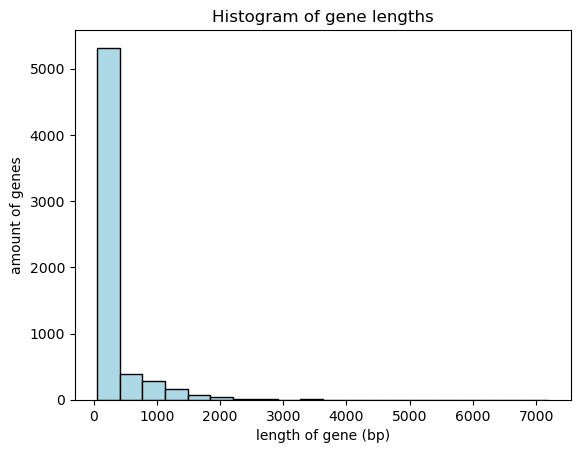

In [12]:
# All together
my_genome = opener("Staphylococcus_aureus_NCTC8325.fasta") 
get_gc(my_genome) 
print("\n")

from re import *
my_genes = get_genes(my_genome)    
print("\n")

my_proteins = get_amino(my_genes)
explore_amino(my_proteins) 
print("\n")

my_small = get_small_prot(my_proteins)
get_second_str(my_small)  
print("\n")

import matplotlib.pyplot as plt
explore_genes(my_genes)

There are 2683 (presumably) proteins in Staphylococcus aureus which content from 20 to 30 amino acids.